In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk


In [2]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
df = pd.read_csv("../data/processed/reviews_processed.csv")

df.head()


,review_id,review_text,rating,review_date,review_year,review_month,bank_code,bank_name,user_name,thumbs_up,text_length,source
0,7a0302f8-ef2f-4b7e-919d-d88b0ba6f80a,"Easy,fast and more services.",5,2025-12-23,2025,12,Amharabank,Amharabank,Ermirutayared Yared,0,28,Google Play
1,af0e660c-8aa7-4123-b635-3135f036715a,nice,5,2025-12-19,2025,12,Amharabank,Amharabank,Animut Tilahun,0,4,Google Play
2,78f50ee0-6087-4b96-bae1-f1f5a819dfd6,good bank,5,2025-12-14,2025,12,Amharabank,Amharabank,Biniyam Eyob,0,9,Google Play
3,a061be6c-9bc4-4ab6-8e46-eb742499eb0e,good,5,2025-12-13,2025,12,Amharabank,Amharabank,Jeme 99,0,4,Google Play
4,a905cb2d-0075-4c06-81a1-b91ba37a9bcf,best,3,2025-12-11,2025,12,Amharabank,Amharabank,TOLESA Bey,0,4,Google Play


In [4]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Function to get compound score
def vader_compound(text):
    return sia.polarity_scores(text)["compound"]

# Apply to the correct column
df["vader_compound"] = df["review_text"].astype(str).apply(vader_compound)

# Function to convert compound score to label
def vader_label(c):
    if c >= 0.05:
        return "positive"
    elif c <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["vader_compound"].apply(vader_label)

# Check results
df[["review_text", "vader_compound", "sentiment"]].head()


,review_text,vader_compound,sentiment
0,"Easy,fast and more services.",0.0000,neutral
1,nice,0.4215,positive
2,good bank,0.4404,positive
3,good,0.4404,positive
4,best,0.6369,positive


In [5]:
df.columns


Index(['review_id', 'review_text', 'rating', 'review_date', 'review_year',
       'review_month', 'bank_code', 'bank_name', 'user_name', 'thumbs_up',
       'text_length', 'source', 'vader_compound', 'sentiment'],
      dtype='object')

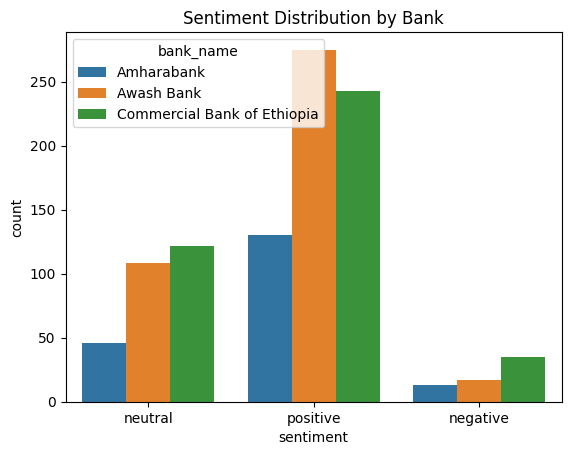

In [6]:
sns.countplot(data=df, x="sentiment", hue="bank_name")
plt.title("Sentiment Distribution by Bank")
plt.show()

In [7]:
import os

PROJECT_ROOT = r"C:\Users\hp\Documents\bank-customer-experience-analytics"
os.makedirs(os.path.join(PROJECT_ROOT, "data/processed"), exist_ok=True)

output_path = os.path.join(PROJECT_ROOT, "data/processed/reviews_with_sentiment.csv")
df.to_csv(output_path, index=False)
print("File saved at:", output_path)


File saved at: C:\Users\hp\Documents\bank-customer-experience-analytics\data/processed/reviews_with_sentiment.csv
